# Question 3 : AutoEncoders

In [155]:
import numpy as np
import matplotlib.pyplot as plt
import os
import time
import datetime
from tqdm import tqdm
import random
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

In [ ]:
# Some preliminary code
def add_username(username) -> None:
    plt.text(0.95, 0.95, username, ha="right", va="top", transform=plt.gca().transAxes, fontsize=10, color="gray", alpha=0.7)

def print_separator() -> None:
    print("\n" + "="*50 + "\n")

# Set random seed for reproducibility
random.seed(42)
np.random.seed(42)

## Question 3.1 : Part 1 - Autoencoder for Image Reconstruction

In [ ]:
# Previously implemented MLP
# ============= Activation Function Classes =============

class ReLU:
    """ReLU activation function."""
    
    def forward(self, x):
        """Forward pass: max(0, x)"""
        self.input = x # Of size (batch_size, output_width)
        return np.maximum(0, x) # Element-wise max
    
    def backward(self, grad_output):
        """Backward pass: derivative is 1 if x > 0, else 0"""
        return grad_output * (self.input >= 0) # Of same shape as input


class Tanh:
    """Tanh activation function."""
    
    def forward(self, x):
        """Forward pass: tanh(x)"""
        self.output = np.tanh(x) # Of size (batch_size, output_width)
        return self.output # Element-wise tanh
    
    def backward(self, grad_output):
        """Backward pass: derivative is 1 - tanh^2(x)"""
        return grad_output * (1 - self.output ** 2) # Of same shape as input


class Sigmoid:
    """Sigmoid activation function."""
    
    def forward(self, x):
        """Forward pass: 1 / (1 + exp(-x))"""
        self.output = 1 / (1 + np.exp(-np.clip(x, -500, 500))) # Clip to prevent overflow, Of size (batch_size, output_width)
        return self.output # Element-wise sigmoid
    
    def backward(self, grad_output):
        """Backward pass: sigmoid(x) * (1 - sigmoid(x))"""
        return grad_output * self.output * (1 - self.output) # Of same shape as input


class Identity:
    """Identity activation (no activation)."""
    
    def forward(self, x):
        """Forward pass: returns input as-is"""
        return x # Of size (batch_size, output_width)
    
    def backward(self, grad_output):
        """Backward pass: gradient passes through unchanged"""
        return grad_output # Of same shape as input

# ============= Linear Layer Class =============

class Linear:
    """Linear (fully connected) layer."""
    
    def __init__(self, input_width, output_width, activation='relu'):
        """
        Initialize linear layer.
        
        Args:
            input_width: Number of input features
            output_width: Number of output features
            activation: Activation function name ('relu', 'tanh', 'sigmoid', 'identity')
        """

        random.seed(42)
        np.random.seed(42)

        self.input_width = input_width
        self.output_width = output_width
        
        # Initialize weights and biases using Xavier initialization
        self.weights = np.random.randn(input_width, output_width) * np.sqrt(2.0 / input_width)
        self.biases = np.zeros((1, output_width))
        
        # Initialize cumulative gradients
        self.grad_weights = np.zeros_like(self.weights)
        self.grad_biases = np.zeros_like(self.biases)
        
        # Set activation function
        activation_map ={
            'relu': ReLU(),
            'tanh': Tanh(),
            'sigmoid': Sigmoid(),
            'identity': Identity()
        }
        # Get the 'Value' value from the key in the dictionary, pass the key in all lowercase, dedfault to ReLU
        self.activation = activation_map.get(activation.lower(), ReLU())
        
        # Store for backward pass
        self.input = None
        self.z = None
        self.output = None
    
    def forward(self, x):
        """
        Forward pass.
        
        Args:
            x: Input of shape (batch_size, input_width)
            
        Returns:
            Output after linear transformation and activation
        """
        self.input = x # Of size (batch_size, input_width)
        self.z = np.dot(x, self.weights) + self.biases # Of size (batch_size, output_width)
        self.output = self.activation.forward(self.z) # Of size (batch_size, output_width)
        return self.output # Of size (batch_size, output_width)
    
    def backward(self, grad_output):
        """
        Backward pass.
        
        Args:
            grad_output: Gradient from next layer
            
        Returns:
            Gradient to pass to previous layer
        """
        # Gradient through activation
        grad_z = self.activation.backward(grad_output) # Of size (batch_size, output_width)
        
        # Accumulate gradients for weights and biases
        self.grad_weights += np.dot(self.input.T, grad_z) # Of size (input_width, output_width)
        self.grad_biases += np.sum(grad_z, axis=0, keepdims=True) # Of size (1, output_width)
        
        # Gradient to pass to previous layer
        grad_input = np.dot(grad_z, self.weights.T) # Of size (batch_size, input_width)
        
        return grad_input # Of size (batch_size, input_width)

# ============= Loss Functions =============

class MSE:
    """Mean Squared Error loss function."""
    
    def forward(self, y_pred, y_true):
        """Compute MSE loss."""
        self.y_pred = y_pred # Of size (batch_size, output_width)
        self.y_true = y_true # Of size (batch_size, output_width)
        return np.sum(np.mean((y_pred - y_true) ** 2, axis=1)) # Scalar
    
    def backward(self):
        """Compute gradient of MSE loss."""
        batch_size, output_size = self.y_pred.shape
        return 2 * (self.y_pred - self.y_true) / (output_size) # Of size (batch_size, output_width)


class BCE:
    """Binary Cross Entropy loss function."""
    
    def forward(self, y_pred, y_true):
        """Compute BCE loss."""
        self.y_pred = np.clip(y_pred, 1e-7, 1 - 1e-7) # Of size (batch_size, output_width)
        self.y_true = y_true # Of size (batch_size, output_width)
        return np.sum(-np.mean(y_true * np.log(self.y_pred) + (1 - y_true) * np.log(1 - self.y_pred), axis=1)) # Scalar
    
    def backward(self):
        """Compute gradient of BCE loss."""
        batch_size, output_size = self.y_pred.shape
        return (self.y_pred - self.y_true) / (self.y_pred * (1 - self.y_pred) * output_size) # Of size (batch_size, output_width)

# ============= Model Class =============

class Model:
    """Neural network model."""
    
    def __init__(self, layers, loss_type='mse'):
        """
        Initialize model.
        
        Args:
            layers: List of Linear layer objects
            loss_type: 'mse' or 'bce'
        """
        self.layers = layers

        if loss_type.lower() == 'mse':
            self.loss_fn = MSE()
        elif loss_type.lower() == 'bce':
            self.loss_fn = BCE()
        else:
            raise ValueError(f"Unknown loss type: {loss_type}")
    
    def forward(self, x):
        """
        Forward pass through all layers.
        
        Args:
            x: Input data
            
        Returns:
            Output predictions
        """
        for layer in self.layers:
            x = layer.forward(x)
        return x
    
    def backward(self, grad_output):
        """
        Backward pass through all layers.
        
        Args:
            grad_output: Gradient from loss function
        """
        for layer in reversed(self.layers):
            grad_output = layer.backward(grad_output)
        return grad_output
    
    def train(self, x, y):
        """
        Perform one training step: forward pass, compute loss, backward pass.
        
        Args:
            x: Input data
            y: True labels
            
        Returns:
            loss: Computed loss value
        """
        # Forward pass
        y_pred = self.forward(x)
        
        # Compute loss
        loss = self.loss_fn.forward(y_pred, y)
        
        # Backward pass
        grad_loss = self.loss_fn.backward()
        self.backward(grad_loss)
        
        return loss
    
    def zero_grad(self):
        """Reset cumulative gradients in all layers to zero."""
        for layer in self.layers:
            layer.grad_weights.fill(0)
            layer.grad_biases.fill(0)
    
    def update(self, learning_rate):
        """
        Update model parameters using accumulated gradients.
        
        Args:
            learning_rate: Learning rate for gradient descent
        """
        for layer in self.layers:
            layer.weights -= learning_rate * layer.grad_weights
            layer.biases -= learning_rate * layer.grad_biases
    
    def predict(self, x):
        """
        Make predictions (forward pass without training).
        
        Args:
            x: Input data
            
        Returns:
            Predictions
        """
        return self.forward(x)
    
    def save_to(self, path, loss):
        """
        Save model parameters to file.
        
        Args:
            path: Path to save file (.npz format)
            loss: Loss value to include in filename
        """
        params = {}
        for i, layer in enumerate(self.layers):
            params[f'layer_{i}_weights'] = layer.weights
            params[f'layer_{i}_biases'] = layer.biases
        
        # Save architecture info
        architecture = {
            'num_layers': len(self.layers),
            'layer_shapes': [(layer.input_width, layer.output_width) for layer in self.layers],
            'activations': [layer.activation for layer in self.layers]
        }

        # Delete the previously saved model to save space
        for file in os.listdir(path):
            if file.startswith("model_loss_") and file.endswith(".npz"):
                os.remove(os.path.join(path, file))
    
        full_path = os.path.join(path, f"model_loss_{loss:.6f}.npz")
        np.savez(full_path, architecture=architecture, **params, loss=loss) # Unpacks params dict
        # print(f"Model saved to {full_path}")

    def load_from(self, path):
        """
        Load model parameters from file.
        
        Args:
            path: Path to saved file (.npz format)
        """
        data = np.load(path, allow_pickle=True) # To load non-numpy elements like dicts
        architecture = data['architecture'].item()
        
        # Verify architecture matches
        if len(self.layers) != architecture['num_layers']:
            raise ValueError("Model architecture doesn't match saved file!")
        
        for i, layer in enumerate(self.layers):
            expected_shape = architecture['layer_shapes'][i]
            if (layer.input_width, layer.output_width) != expected_shape:
                raise ValueError(f"Layer {i} shape mismatch!")
            
            layer.weights = data[f'layer_{i}_weights']
            layer.biases = data[f'layer_{i}_biases']
        
        print(f"Model loaded from {path}")



def plot_training_history(history):
    """
    Plot training loss vs epochs.
    
    Args:
        history: Dictionary from train_model
    """
    epoch_loss_history = history['loss_history']
    batch_loss_history = history['batch_loss_history']
    
    epochs = len(epoch_loss_history)
    epochs_axis = np.arange(1, epochs + 1)
    
    plt.figure(figsize=(10, 6))
    plt.plot(epochs_axis, epoch_loss_history, linewidth=2, label='Epoch Loss')
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Loss per epoch', fontsize=12)
    plt.title(f'Training Loss vs Epochs', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    add_username("siddarth.g")
    # plt.ylim([0, 5e4])
    plt.show()

    # Loss vs samples seen
    # x_ticks = np.arange(1, len(history['grad_update_loss']) + 1) * history['hyperparameters']['batch_size'] * history['hyperparameters']['grad_accumulation_steps']

    # plt.figure(figsize=(10, 6))
    # plt.plot(x_ticks, history['grad_update_loss'], linewidth=2, label='Batch Loss')
    # plt.xlabel('Total Samples Seen', fontsize=12)
    # plt.ylabel('Loss per Grad Update', fontsize=12)
    # plt.title(f'Training Loss vs Total Samples Seen', fontsize=14)
    # plt.grid(True, alpha=0.3)
    # plt.tight_layout()
    # add_username("siddarth.g")
    # plt.show()

In [158]:
class MLPAutoencoder:
    """
    An MLP-based Autoencoder class.
    It encapsulates an encoder and a decoder.
    """ 
    def __init__(self, encoder_layers, decoder_layers, loss='mse'):
        """
        Initializes the autoencoder by creating separate Model instances
        for the encoder and decoder.

        Args:
            encoder_layers (list): A list of Linear layer objects for the encoder.
            decoder_layers (list): A list of Linear layer objects for the decoder.
            loss_fn_type (str): The type of loss function to use ('mse' or 'bce').
        """
        # The encoder compresses the input to a lower-dimensional bottleneck
        self.encoder = Model(encoder_layers, loss)
        
        # The decoder reconstructs the input from the bottleneck representation
        self.decoder = Model(decoder_layers, loss)
    
    def forward(self, x):
        """Performs a full forward pass through the encoder and then the decoder."""
        encoded_representation = self.encoder.forward(x)
        reconstructed_output = self.decoder.forward(encoded_representation)
        return reconstructed_output
    
    def train(self, x):
        """
        Performs one full training step on an input batch 'x'.
        The goal is to reconstruct 'x', so the input and target are the same.
        """
        # Get the reconstructed output from the forward pass
        y_pred = self.forward(x)

        # Calculate the reconstruction loss and its initial gradient
        loss = self.decoder.loss_fn.forward(y_pred, x) 
        ## here, output should be equal to input thats why taking loss with y_pred and x

        grad_loss = self.decoder.loss_fn.backward()

        # Perform the backward pass
        grad_from_decoder = self.decoder.backward(grad_loss)
        self.encoder.backward(grad_from_decoder)
        
        return loss
    
    def zero_grad(self):
        """Resets accumulated gradients in both the encoder and decoder."""
        self.encoder.zero_grad()
        self.decoder.zero_grad()

    def update(self, learning_rate):
        """Updates parameters for both the encoder and decoder and resets gradients."""
        self.encoder.update(learning_rate)
        self.decoder.update(learning_rate)

Fetching MNIST dataset...
Fetched Dataset

Training data shape: (60000, 784)
Testing data shape: (10000, 784)


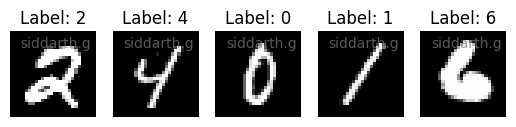

In [159]:
print("Fetching MNIST dataset...")
# 'mnist_784' is the standard name for the 28x28 flattened version
data = fetch_openml('mnist_784', version=1)
print("Fetched Dataset")

# The data is in a Bunch object, similar to a dictionary
# X contains the image data (as a Pandas DataFrame)
# y contains the labels (as a Pandas Series)
X, y = data.data, data.target
X = X.to_numpy()
y = y.to_numpy()

# Normalize the pixel values to the range [0, 1]
X = X.astype('float32') / 255.0

# For your autoencoder, the image itself is the target
# Split into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=10000, random_state=42, shuffle=True)

print(f"\nTraining data shape: {x_train.shape}")
print(f"Testing data shape: {x_test.shape}")

# Print demographic of each digit in training set
# (unique, counts) = np.unique(y_train, return_counts=True)
# print("Training set demographics:")
# for u, c in zip(unique, counts):
#     print(f"Digit {u}: {c} samples")

# Display a few images from the dataset
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
    plt.axis('off')
    plt.title(f"Label: {y_train[i]}")
    add_username("siddarth.g")

In [160]:
# Define the architecture for the autoencoder
input_size = 28 * 28  # MNIST images are 28x28 pixels
bottleneck_dim = 32   # The size of the compressed representation

# Define the layers for the encoder and decoder
encoder_layers = [
    Linear(input_width=input_size, output_width=256, activation='tanh'),
    Linear(input_width=256, output_width=128, activation='tanh'),
    Linear(input_width=128, output_width=64, activation='tanh'),
    Linear(input_width=64, output_width=bottleneck_dim, activation='tanh')
]
decoder_layers = [
    Linear(input_width=bottleneck_dim, output_width=64, activation='tanh'),
    Linear(input_width=64, output_width=128, activation='tanh'),
    Linear(input_width=128, output_width=256, activation='tanh'),
    Linear(input_width=256, output_width=input_size, activation='sigmoid') # Output values in [0, 1]
]

autoencoder = MLPAutoencoder(encoder_layers, decoder_layers, loss='mse')

In [ ]:
# ============= Training Procedure =============

def train_autoencoder(model, X_train, batch_size, grad_accumulation_steps, 
                learning_rate, num_epochs, patience=10, relative_loss_threshold=0.01):
    """
    Training procedure with early stopping.
    
    Args:
        model: Model instance
        X_train: Training data
        batch_size: Batch size
        grad_accumulation_steps: Number of steps to accumulate gradients
        learning_rate: Learning rate
        num_epochs: Maximum number of epochs
        patience: Number of epochs for early stopping
        relative_loss_threshold: Threshold for early stopping (default 0.01)
    
    Returns:
        Dictionary with training history and metadata
    """

    random.seed(42)
    np.random.seed(42)

    n_samples = X_train.shape[0]
    n_batches = n_samples // batch_size
    
    epoch_loss_history = []
    batch_loss_history = []
    grad_update_loss = []
    print(f"Starting training:")
    print(f"Total samples: {n_samples}, Batch size: {batch_size}, Batches per epoch: {n_batches}")
    print(f"Gradient accumulation steps: {grad_accumulation_steps}")
    print(f"Learning rate: {learning_rate}, Max epochs: {num_epochs}")
    print_separator()
    
    best_loss = float('inf')
    epochs_without_improvement = 0
    
    # Create progress bar for epochs
    pbar = tqdm(range(num_epochs), desc="Training", unit="epoch")
    #desc = description shown at the left of the progress bar
    #unit = unit of each iteration
    
    for epoch in pbar:
        # Shuffle data
        indices = np.random.permutation(n_samples)
        X_shuffled = X_train[indices]
        # y_shuffled = y_train[indices]
        
        epoch_loss = 0
        grad_update_loss_val = 0
        model.zero_grad()
        
        for batch_idx in range(n_batches):
            # Get batch
            start_idx = batch_idx * batch_size
            end_idx = start_idx + batch_size
            X_batch = X_shuffled[start_idx:end_idx]
            y_batch = y_shuffled[start_idx:end_idx]
            
            # Train on batch
            loss = model.train(X_batch)
            batch_loss_history.append(loss)
            epoch_loss += loss
            grad_update_loss_val += loss
            
            # Update parameters after grad_accumulation_steps
            if (batch_idx + 1) % grad_accumulation_steps == 0:
                grad_update_loss.append(grad_update_loss_val)
                model.update(learning_rate)
                model.zero_grad()
        
        # Update if there are remaining gradients
        # Choose batch sizes and grad_accumulation_steps such that this condition is not needed
        # Will affect the plot if this gets executed
        if n_batches % grad_accumulation_steps != 0:
            model.update(learning_rate)
            model.zero_grad()
        
        # Average loss for epoch (not per batch)
        avg_loss = epoch_loss
        epoch_loss_history.append(avg_loss)
        
        # Update progress bar with current metrics
        pbar.set_postfix({
            'loss': f'{avg_loss:.6f}',
            'best': f'{best_loss:.6f}',
            'no_improve': epochs_without_improvement
        })
        # Display other values in the postfix
    
        if epoch == 0:
            best_loss = avg_loss
        
        # Early stopping check
        if avg_loss < best_loss:
            if best_loss - avg_loss > relative_loss_threshold * best_loss:
                epochs_without_improvement = 0
                best_loss = avg_loss
                # model.save_to(save_path, best_loss)
            else:
                epochs_without_improvement += 1
        else:
            epochs_without_improvement += 1
        
        # Check early stopping condition
        if epochs_without_improvement >= patience:
            L_i = epoch_loss_history[-1]
            L_i_minus_10 = epoch_loss_history[-10]
            pbar.write(f"\nEarly stopping triggered at epoch {epoch + 1}") # Writes to console without breaking progress bar
            pbar.write(f"Loss improvement less than 1% over last {patience} epochs")
            break

    pbar.close()
    print_separator()
    print(f"Training completed! Best loss: {best_loss:.6f}, total epochs: {len(epoch_loss_history)}")
    
    # Create training history
    history = {
        'loss_history': epoch_loss_history,
        'batch_loss_history': batch_loss_history,
        'grad_update_loss': grad_update_loss,
        'hyperparameters': {
            'batch_size': batch_size,
            'grad_accumulation_steps': grad_accumulation_steps,
            'learning_rate': learning_rate,
            'num_epochs': len(epoch_loss_history),
            'patience': patience,
            'relative_loss_threshold': relative_loss_threshold
        },
        'final_loss': epoch_loss_history[-1],
        'best_loss': best_loss
    }

    plot_training_history(history)
    
    return history

Starting training:
Total samples: 60000, Batch size: 600, Batches per epoch: 100
Gradient accumulation steps: 1
Learning rate: 1, Max epochs: 100




Training:  98%|█████████▊| 98/100 [07:46<00:09,  4.76s/epoch, loss=1.629505, best=1.643248, no_improve=9]


Early stopping triggered at epoch 99
Loss improvement less than 1% over last 10 epochs


Training completed! Best loss: 1.643248, total epochs: 99


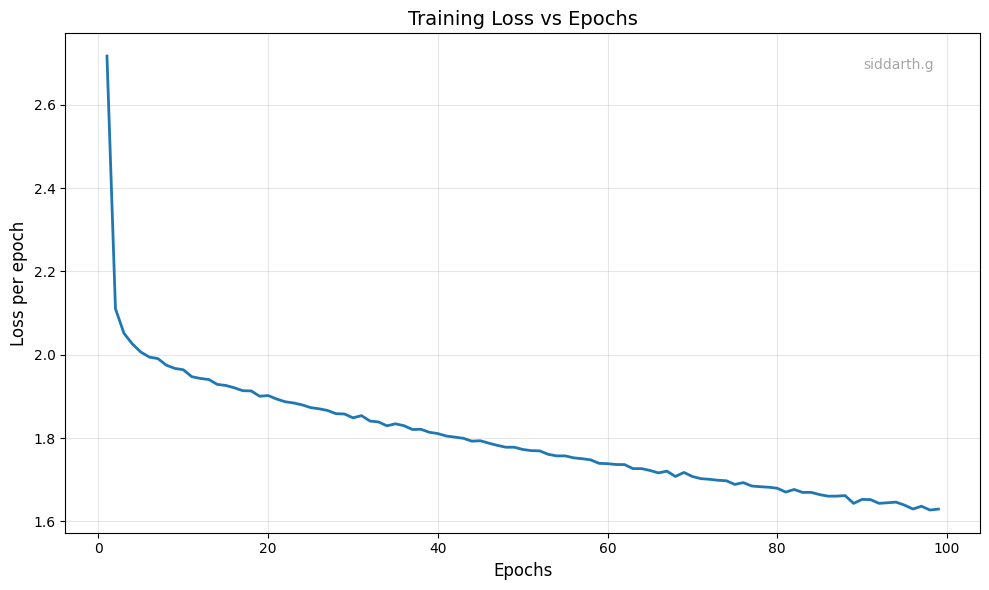

In [ ]:
history = train_autoencoder(
    model=autoencoder,
    X_train=x_train,
    batch_size=600,
    grad_accumulation_steps=1,
    learning_rate=1,
    num_epochs=100,
    patience=10,
    relative_loss_threshold=0.01,
)

In [170]:
def visualize(autoencoder, x_test, y_test, seed=42):
    """
    Visualizes the results of an autoencoder by showing original and reconstructed images.
    
    Args:
        autoencoder: The trained autoencoder model
        x_test: Test data (images)
        y_test: Test labels
        digits_to_show: Number of digits to display (default: 10)
        seed: Random seed for reproducibility
        
    Returns:
        fig: The matplotlib figure object
    """
    random.seed(42)
    np.random.seed(42)
        
    indices = []
    
    for digit in range(10):
        digit_indices = np.where(y_test.astype(int) == digit)[0]
        if len(digit_indices) > 0:
            indices.append(np.random.choice(digit_indices))
    
    # Get originals and reconstructions
    originals = x_test[indices]
    reconstructed = autoencoder.forward(originals)

    # Print the values in the range [0.25, 0.75] in reconstructed
    # print("Reconstructed values in range [0.25, 0.75]:")
    # print(reconstructed[(reconstructed >= 0.25) & (reconstructed <= 0.75)])
    
    # Calculate reconstruction error for each image
    reconstruction_errors = np.mean((originals - reconstructed)**2, axis=1)
    
    # Plot
    fig, axes = plt.subplots(2, 10, figsize=(16, 5))
    fig.suptitle("Original and Reconstructed Images - MSE", fontsize=16)
    
    for i in range(10):
        digit = int(y_test[indices[i]])
        error = reconstruction_errors[i]
        
        # Original
        axes[0, i].imshow(originals[i].reshape(28, 28), cmap='gray', vmin=0, vmax=1)
        axes[0, i].set_title(f"Original: {digit}")
        axes[0, i].axis('off')
        
        # Reconstructed
        axes[1, i].imshow(reconstructed[i].reshape(28, 28), cmap='gray', vmin=0, vmax=1)
        axes[1, i].set_title(f"{error:.4f}")
        axes[1, i].axis('off')
    
    plt.tight_layout()
    add_username("siddarth.g")
    
    plt.show()

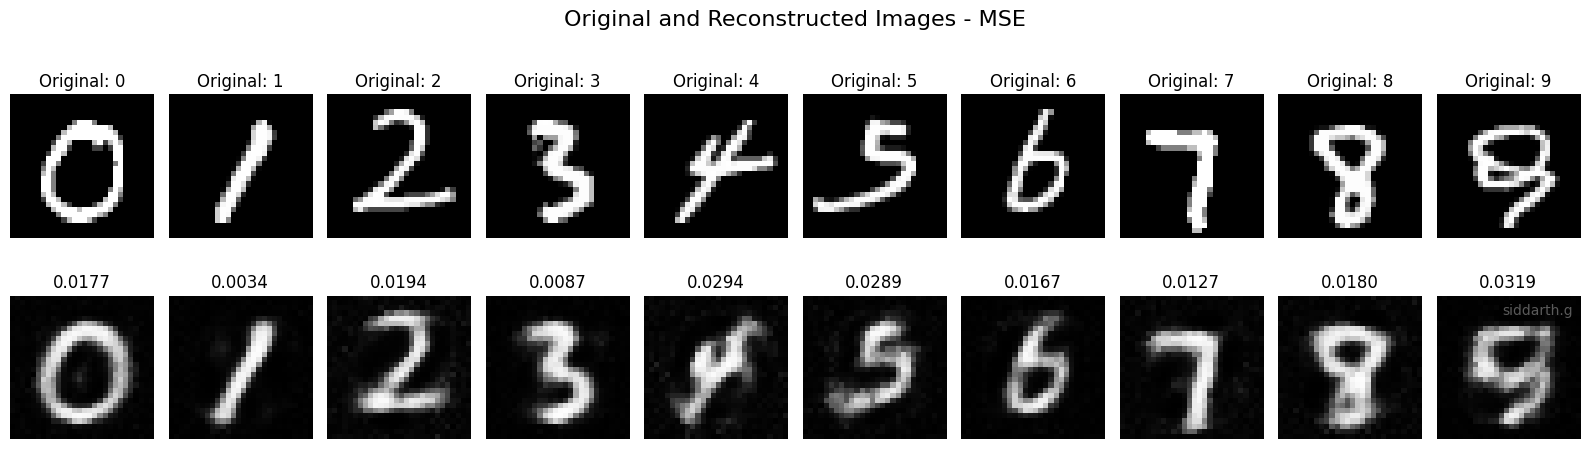

In [171]:
visualize(autoencoder, x_test, y_test)